# Network Flow Inference Notebook
XGBoost inference on CICIDS2017 network flow CSVs with ground truth evaluation.

**Pipeline:** Load → Preprocess → Infer → Evaluate vs ground truth → Visualize

In [5]:
import sys
print(sys.executable)

/home/cpre560/miniconda3/envs/cpre560/bin/python


In [6]:
# === CELL 1: Imports & Paths ===
import xgboost as xgb
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from IPython.display import display

MODEL_PATH     = "models/baseline_xgboost.json"
ARTIFACTS_PATH = "models/preprocessing_info.pkl"
RENAME_MAP_PATH = "rename_map.pkl"
#CSV_PATH       = "./data/flows.csv"
CSV_PATH = "./data/updated_slowloris.csv" 

# Ground truth column name in the CSV (set None to skip GT evaluation)
GROUND_TRUTH_COL = "Label"

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
})
PALETTE = {"BENIGN": "#1D9E75", "DDoS": "#D85A30", "other": "#7F77DD"}
print("Imports OK")

Imports OK


In [7]:
# === CELL 2: Load Model & Artifacts ===
model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

with open(ARTIFACTS_PATH, "rb") as f:
    artifacts = pickle.load(f)

le_target    = artifacts["target_encoder"]
feature_cols = artifacts["feature_columns"]

with open(RENAME_MAP_PATH, "rb") as f:
    rename_map = pickle.load(f)

print(f"Model loaded  |  Classes: {list(le_target.classes_)}")
print(f"Feature count: {len(feature_cols)}")

Model loaded  |  Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Feature count: 70


In [8]:
# === CELL 3: Load & Preprocess CSV ===
df_raw = pd.read_csv(CSV_PATH)
df_raw.columns = df_raw.columns.str.strip()
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
df_raw.rename(columns=rename_map, inplace=True)

# CICIDS2017 duplicate header fix
df_raw["Fwd Header Length.1"] = df_raw["Fwd Header Length"]

# Stash ground truth BEFORE dropping rows so index alignment is preserved
has_gt = GROUND_TRUTH_COL is not None and GROUND_TRUTH_COL in df_raw.columns
if has_gt:
    gt_series = df_raw[GROUND_TRUTH_COL].str.strip()
else:
    gt_series = None
    print(f"WARNING: '{GROUND_TRUTH_COL}' column not found — skipping ground truth eval.")

missing = [c for c in feature_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing feature columns after rename: {missing}")

# Drop rows with NaN in features (keep GT aligned via index)
df_raw.dropna(subset=feature_cols, inplace=True)
X = df_raw[feature_cols]

if has_gt:
    y_true = gt_series.loc[df_raw.index]  # aligned after dropna

print(f"Loaded {len(X):,} flows  |  Features: {X.shape[1]}")
if has_gt:
    print("Ground truth distribution:")
    display(y_true.value_counts().rename_axis("Label").reset_index(name="Count"))

Loaded 1,004 flows  |  Features: 70
Ground truth distribution:


,Label,Count
0,DoS slowloris,1004


In [9]:
# === CELL 4: Run Inference ===
y_pred       = model.predict(X)
y_pred_proba = model.predict_proba(X)
y_pred_label = le_target.inverse_transform(y_pred)
confidence   = y_pred_proba.max(axis=1)

results = pd.DataFrame(index=df_raw.index)
results["Predicted_Label"]    = y_pred_label
results["Predicted_Class_ID"] = y_pred
results["Confidence"]         = confidence.round(4)

if has_gt:
    results["Ground_Truth"] = y_true
    results["Correct"]      = results["Predicted_Label"] == results["Ground_Truth"]

# Add per-class probability columns
for i, cls in enumerate(le_target.classes_):
    results[f"Prob_{cls}"] = y_pred_proba[:, i].round(4)

results.to_csv("inference_results.csv", index=False)
print(f"Inference complete — {len(results):,} predictions saved to inference_results.csv")
print("\nPrediction distribution:")
display(results["Predicted_Label"].value_counts().rename_axis("Predicted").reset_index(name="Count"))

Inference complete — 1,004 predictions saved to inference_results.csv

Prediction distribution:


,Predicted,Count
0,BENIGN,1001
1,DDoS,3


In [10]:
# === CELL 6: Ground Truth Evaluation (skipped if no GT column) ===
if not has_gt:
    print("Ground truth column not found — skipping this cell.")
else:
    y_true_vals = results["Ground_Truth"]
    y_pred_vals = results["Predicted_Label"]

    acc       = accuracy_score(y_true_vals, y_pred_vals)
    f1_macro  = f1_score(y_true_vals, y_pred_vals, average="macro",  zero_division=0)
    f1_weight = f1_score(y_true_vals, y_pred_vals, average="weighted", zero_division=0)
    prec      = precision_score(y_true_vals, y_pred_vals, average="macro", zero_division=0)
    rec       = recall_score(y_true_vals, y_pred_vals, average="macro",  zero_division=0)

    print("=" * 50)
    print(f"  Accuracy          : {acc*100:.2f}%")
    print(f"  Macro F1          : {f1_macro*100:.2f}%")
    print(f"  Weighted F1       : {f1_weight*100:.2f}%")
    print(f"  Macro Precision   : {prec*100:.2f}%")
    print(f"  Macro Recall      : {rec*100:.2f}%")
    print("=" * 50)
    print()
    print(classification_report(y_true_vals, y_pred_vals, zero_division=0))

    # Save misclassified rows for inspection
    misclassified = results[~results["Correct"]]
    misclassified.to_csv("misclassified_flows.csv", index=False)
    print(f"Misclassified rows : {len(misclassified):,} / {len(results):,}  "
          f"({len(misclassified)/len(results)*100:.2f}%)")
    print("Saved → misclassified_flows.csv")

  Accuracy          : 0.00%
  Macro F1          : 0.00%
  Weighted F1       : 0.00%
  Macro Precision   : 0.00%
  Macro Recall      : 0.00%

               precision    recall  f1-score   support

       BENIGN       0.00      0.00      0.00       0.0
         DDoS       0.00      0.00      0.00       0.0
DoS slowloris       0.00      0.00      0.00    1004.0

     accuracy                           0.00    1004.0
    macro avg       0.00      0.00      0.00    1004.0
 weighted avg       0.00      0.00      0.00    1004.0

Misclassified rows : 1,004 / 1,004  (100.00%)
Saved → misclassified_flows.csv


In [11]:
# === CELL 6b: Per-Class Ground Truth Performance Table (Interactive, Sortable) ===
# Renders a styled, sortable HTML table inline in the notebook output.
# Click any column header to sort ascending; click again to sort descending.

if not has_gt:
    print("Ground truth not available — skipping per-class table.")
else:
    from IPython.display import HTML
    from sklearn.metrics import classification_report

    y_true_vals = results["Ground_Truth"]
    y_pred_vals = results["Predicted_Label"]

    # Build per-class stats
    report = classification_report(
        y_true_vals, y_pred_vals,
        output_dict=True, zero_division=0
    )

    rows = []
    all_classes = sorted(y_true_vals.unique())
    for cls in all_classes:
        gt_count      = int((y_true_vals == cls).sum())
        pred_count    = int((y_pred_vals == cls).sum())
        correct       = int(((y_true_vals == cls) & (y_pred_vals == cls)).sum())
        misclassified = gt_count - correct
        pct_correct   = (correct / gt_count * 100) if gt_count > 0 else 0.0
        pct_misc      = (misclassified / gt_count * 100) if gt_count > 0 else 0.0
        r = report.get(cls, {})
        precision     = r.get("precision", 0.0)
        recall        = r.get("recall",    0.0)   # == per-class accuracy for GT class
        f1            = r.get("f1-score",  0.0)
        rows.append({
            "Attack Class":     cls,
            "GT Count":         gt_count,
            "Predicted Count":  pred_count,
            "Correct":          correct,
            "Misclassified":    misclassified,
            "% Correct":        round(pct_correct, 2),
            "% Misclassified":  round(pct_misc,    2),
            "Precision":        round(precision * 100, 2),
            "Recall":           round(recall    * 100, 2),
            "F1 Score":         round(f1        * 100, 2),
        })

    perf_df = pd.DataFrame(rows)

    # ---- HTML rendering with inline sort ----
    cols = list(perf_df.columns)

    def pct_bar(val, color):
        """Tiny inline progress bar for percentage columns."""
        bar_w = min(max(val, 0), 100)
        return (
            f'<div style="display:flex;align-items:center;gap:6px;">'
            f'<div style="flex:1;background:#eee;border-radius:3px;height:7px;">'
            f'<div style="width:{bar_w}%;background:{color};border-radius:3px;height:7px;"></div></div>'
            f'<span style="min-width:46px;text-align:right;">{val:.1f}%</span></div>'
        )

    def score_badge(val):
        """Color-coded badge for metric scores."""
        if val >= 90:   bg, tc = "#EAF3DE", "#27500A"
        elif val >= 60: bg, tc = "#FFF8E1", "#5D4037"
        elif val > 0:   bg, tc = "#FCEBEB", "#791F1F"
        else:           bg, tc = "#F1EFE8", "#5F5E5A"  # zero / not predicted
        return (
            f'<span style="background:{bg};color:{tc};padding:2px 8px;'
            f'border-radius:4px;font-size:12px;font-weight:500;white-space:nowrap;">'
            f'{val:.1f}%</span>'
        )

    header_html = ""
    for c in cols:
        header_html += (
            f'<th onclick="sortTable(this)" '
            f'style="cursor:pointer;padding:8px 10px;background:#f0f0f0;'
            f'border-bottom:2px solid #ccc;white-space:nowrap;user-select:none;font-size:12px;">'
            f'{c} <span class="sort-arrow"></span></th>'
        )

    rows_html = ""
    for _, row in perf_df.iterrows():
        is_benign = row["Attack Class"] == "BENIGN"
        row_bg    = "#f9fff9" if is_benign else "#ffffff"
        cells = ""
        for c in cols:
            v    = row[c]
            style = "padding:7px 10px;border-bottom:0.5px solid #e0e0e0;font-size:12px;"
            if c == "Attack Class":
                content = f'<strong>{v}</strong>'
            elif c == "% Correct":
                content = pct_bar(v, "#1D9E75")
            elif c == "% Misclassified":
                content = pct_bar(v, "#D85A30")
            elif c in ("Precision", "Recall", "F1 Score"):
                content = score_badge(v)
            elif c in ("GT Count", "Predicted Count", "Correct", "Misclassified"):
                content = f'{int(v):,}'
                style  += "text-align:right;"
            else:
                content = str(v)
            # Store raw numeric sort key in data-val for JS
            data_val = v if isinstance(v, (int, float)) else 0
            cells += f'<td data-val="{data_val}" style="{style}">{content}</td>'
        rows_html += f'<tr style="background:{row_bg}">{cells}</tr>'

    html = f"""
<div style="font-family:sans-serif;">
  <p style="font-size:13px;color:#555;margin-bottom:8px;">
    Click any column header to sort. Green = &ge;90%, yellow = 60-89%, red = &lt;60%.
    Row color: <span style='background:#f9fff9;padding:1px 6px;border:1px solid #ccc;border-radius:3px;'>green tint</span> = BENIGN.
  </p>
  <div style="overflow-x:auto;">
  <table id="perclass-table" style="border-collapse:collapse;width:100%;min-width:900px;">
    <thead><tr>{header_html}</tr></thead>
    <tbody>{rows_html}</tbody>
  </table>
  </div>
</div>
<script>
var _sortState = {{col: -1, asc: true}};
function sortTable(th) {{
  var table  = document.getElementById('perclass-table');
  var tbody  = table.querySelector('tbody');
  var ths    = Array.from(table.querySelectorAll('thead th'));
  var colIdx = ths.indexOf(th);
  var asc    = (_sortState.col === colIdx) ? !_sortState.asc : true;
  _sortState = {{col: colIdx, asc: asc}};
  ths.forEach(function(t) {{ t.querySelector('.sort-arrow').textContent = ''; }});
  th.querySelector('.sort-arrow').textContent = asc ? ' ▲' : ' ▼';
  var rows = Array.from(tbody.querySelectorAll('tr'));
  rows.sort(function(a, b) {{
    var aVal = a.querySelectorAll('td')[colIdx].dataset.val;
    var bVal = b.querySelectorAll('td')[colIdx].dataset.val;
    var aNum = parseFloat(aVal), bNum = parseFloat(bVal);
    if (!isNaN(aNum) && !isNaN(bNum)) {{
      return asc ? aNum - bNum : bNum - aNum;
    }}
    return asc ? aVal.localeCompare(bVal) : bVal.localeCompare(aVal);
  }});
  rows.forEach(function(r) {{ tbody.appendChild(r); }});
}}
</script>
"""
    display(HTML(html))

    # Also save to CSV for reference
    perf_df.to_csv("per_class_performance.csv", index=False)
    print("Saved → per_class_performance.csv")


Attack Class,GT Count,Predicted Count,Correct,Misclassified,% Correct,% Misclassified,Precision,Recall,F1 Score
DoS slowloris,"1,004",0,0,"1,004",0.0%,100.0%,0.0%,0.0%,0.0%


Saved → per_class_performance.csv


/tmp/ipykernel_15767/1285314533.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=classes, patch_artist=True, zorder=2)
/home/cpre560/miniconda3/envs/cpre560/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


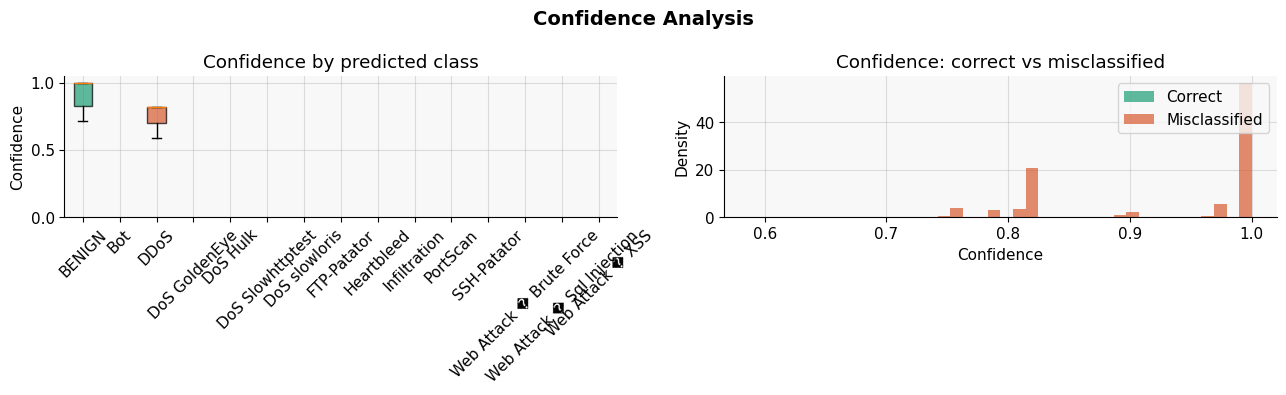

,count,mean,std,min,25%,50%,75%,max
Predicted_Label,,,,,,,,
BENIGN,1001.0,0.9337,0.0887,0.7138,0.8236,0.9997,0.9998,0.9999
DDoS,3.0,0.7415,0.1336,0.5872,0.7029,0.8186,0.8186,0.8186


In [12]:
# === CELL 8: Confidence Analysis (correct vs misclassified) ===
classes = list(le_target.classes_)
colors  = [PALETTE.get(c, PALETTE["other"]) for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Confidence Analysis", fontsize=14, fontweight="bold")

# --- Confidence box plot by predicted class ---
ax = axes[0]
groups = [results.loc[results["Predicted_Label"] == c, "Confidence"].values for c in classes]
bp = ax.boxplot(groups, labels=classes, patch_artist=True, zorder=2)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Confidence by predicted class", fontweight="500")
ax.set_ylabel("Confidence")
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=45)

# --- Correct vs wrong confidence distribution (only with GT) ---
ax = axes[1]
if has_gt:
    ax.hist(results.loc[results["Correct"],  "Confidence"], bins=40, alpha=0.7,
            color="#1D9E75", label="Correct",       density=True, zorder=2)
    ax.hist(results.loc[~results["Correct"], "Confidence"], bins=40, alpha=0.7,
            color="#D85A30", label="Misclassified", density=True, zorder=2)
    ax.set_title("Confidence: correct vs misclassified", fontweight="500")
    ax.legend()
else:
    ax.hist(results["Confidence"], bins=40, color="#7F77DD", alpha=0.8, density=True, zorder=2)
    ax.set_title("Overall confidence distribution", fontweight="500")
ax.set_xlabel("Confidence")
ax.set_ylabel("Density")

plt.tight_layout()
plt.savefig("plot_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

# Confidence summary table
conf_summary = results.groupby("Predicted_Label")["Confidence"].describe().round(4)
display(conf_summary)

These flows were all low on the confidence prediciton indicating the model performed poorly on these flows
Flows below 90% confidence: 355 (35.36% of total)

Low-confidence prediction breakdown by flow count:


Predicted_Label
BENIGN    352
DDoS        3
Name: count, dtype: int64


Correct within low-conf set: 0 / 355 (0.0%)


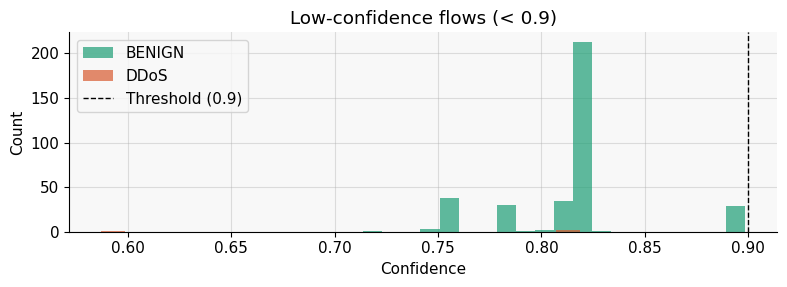

Saved → low_confidence_flows.csv


In [13]:
# === CELL 9: Low-Confidence Flow Inspection ===

CONF_THRESHOLD = 0.90  # adjust as needed
print("These flows were all low on the confidence prediciton indicating the model performed poorly on these flows")

low_conf = results[results["Confidence"] < CONF_THRESHOLD].copy()
print(f"Flows below {CONF_THRESHOLD*100:.0f}% confidence: {len(low_conf):,} "
      f"({len(low_conf)/len(results)*100:.2f}% of total)")

if len(low_conf) > 0:
    print("\nLow-confidence prediction breakdown by flow count:")
    display(low_conf["Predicted_Label"].value_counts())

    if has_gt:
        lc_correct = low_conf["Correct"].sum()
        print(f"\nCorrect within low-conf set: {lc_correct} / {len(low_conf)} "
              f"({lc_correct/len(low_conf)*100:.1f}%)")

    # Plot low-confidence confidence distribution
    fig, ax = plt.subplots(figsize=(8, 3))
    for cls, color in zip(classes, colors):
        mask = low_conf["Predicted_Label"] == cls
        if mask.sum() > 0:
            ax.hist(low_conf.loc[mask, "Confidence"], bins=20, alpha=0.7,
                    color=color, label=cls, zorder=2)
    ax.axvline(CONF_THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"Threshold ({CONF_THRESHOLD})")
    ax.set_title(f"Low-confidence flows (< {CONF_THRESHOLD})", fontweight="500")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.savefig("plot_low_confidence.png", dpi=150, bbox_inches="tight")
    plt.show()

    low_conf.to_csv("low_confidence_flows.csv", index=False)
    print("Saved → low_confidence_flows.csv")
else:
    print("No flows below threshold — model is highly confident on all samples.")
    


In [14]:
# === CELL 10: Final Summary ===
print("=" * 55)
print("  INFERENCE RUN SUMMARY")
print("=" * 55)
print(f"  Input file       : {CSV_PATH}")
print(f"  Total flows      : {len(results):,}")
print(f"  Low-conf flows   : {len(results[results['Confidence'] < CONF_THRESHOLD]):,} "
      f"(< {CONF_THRESHOLD})")
print(f"  Mean confidence  : {results['Confidence'].mean():.4f}")
print()
for cls in classes:
    n = (results["Predicted_Label"] == cls).sum()
    print(f"  {cls:<12} : {n:>8,}  ({n/len(results)*100:.3f}%)")
print()
if has_gt:
    print(f"  Accuracy         : {accuracy_score(results['Ground_Truth'], results['Predicted_Label'])*100:.2f}%")
    print(f"  Macro F1         : {f1_score(results['Ground_Truth'], results['Predicted_Label'], average='macro', zero_division=0)*100:.2f}%")
    print(f"  Misclassified    : {(~results['Correct']).sum():,}")
print("=" * 55)
print()
print("Output files:")
print("  inference_results.csv      — all predictions + probabilities")
if has_gt:
    print("  misclassified_flows.csv    — FP + FN rows for inspection")
print("  low_confidence_flows.csv   — predictions below threshold")
print("  plot_overview.png          — label dist + confidence + GT vs pred")
if has_gt:
    print("  plot_evaluation.png        — confusion matrix + per-class metrics")
print("  plot_confidence.png        — confidence breakdown charts")
print("  plot_low_confidence.png    — low-confidence flow distribution")

  INFERENCE RUN SUMMARY
  Input file       : ./data/updated_slowloris.csv
  Total flows      : 1,004
  Low-conf flows   : 355 (< 0.9)
  Mean confidence  : 0.9331

  BENIGN       :    1,001  (99.701%)
  Bot          :        0  (0.000%)
  DDoS         :        3  (0.299%)
  DoS GoldenEye :        0  (0.000%)
  DoS Hulk     :        0  (0.000%)
  DoS Slowhttptest :        0  (0.000%)
  DoS slowloris :        0  (0.000%)
  FTP-Patator  :        0  (0.000%)
  Heartbleed   :        0  (0.000%)
  Infiltration :        0  (0.000%)
  PortScan     :        0  (0.000%)
  SSH-Patator  :        0  (0.000%)
  Web Attack � Brute Force :        0  (0.000%)
  Web Attack � Sql Injection :        0  (0.000%)
  Web Attack � XSS :        0  (0.000%)

  Accuracy         : 0.00%
  Macro F1         : 0.00%
  Misclassified    : 1,004

Output files:
  inference_results.csv      — all predictions + probabilities
  misclassified_flows.csv    — FP + FN rows for inspection
  low_confidence_flows.csv   — prediction